# Combined Crop Temporal TCN Experiment

This notebook trains a masked attentive multi-scale temporal CNN on the combined YieldSAT + Morocco crop-classification dataset. It keeps per-date observation sequences and resamples each field to a fixed-length tensor of 32 timesteps.

**Five-label alignment:**
- YieldSAT `wheat` -> `Wheat`, `corn` -> `Corn`
- YieldSAT non-wheat/non-corn crops are sampled at 10 percent and mapped to `Other crop`
- Morocco `Other crop` remains in the taxonomy and is downweighted during model fitting
- Morocco `Alfalfa` remains Morocco-only
- Morocco `Background` keeps all original background subclasses

**Spectral-only experiment:** 18 AOI-compatible spectral features (9 S2 band means + 9 vegetation index means). Weather is excluded to avoid source-specific shortcuts.

**Architecture:** MaskedAttentiveMultiScaleTCN, a multi-scale temporal CNN with residual Inception-style blocks, learned temporal attention pooling, and label-smoothed weighted cross-entropy.

**Data prerequisites:**
- YieldSAT feature store: `crop_mapping_fields.parquet` + `crop_mapping_observations.parquet` from notebook 05
- Morocco features: `features.parquet` from the Morocco feature-building workflow


## 1. Install Dependencies

Uncomment these commands only when running the notebook in an environment that does not already provide the research dependencies.


In [3]:
# %pip install -q pyarrow scikit-learn pandas numpy matplotlib torch tqdm


## 2. Imports and Configuration

This section imports the notebook dependencies, fixes random seeds, and declares shared paths and sampling settings.


In [4]:
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [5]:
def first_existing_path(candidates: list[Path]) -> Path:
    for path in candidates:
        if path.exists():
            return path
    return candidates[0]


# --- Configuration ---
YIELDSAT_DIR = first_existing_path([
    Path('notebooks/data/yieldsat_crop_mapping_feature_store'),
    Path('data/yieldsat_crop_mapping_feature_store'),
    Path('/content/yieldsat_crop_mapping_feature_store'),
    Path('/content/data/yieldsat_crop_mapping_feature_store'),
])
MOROCCO_PATH = first_existing_path([
    Path('notebooks/data/morocco_crop_irrigation/features.parquet'),
    Path('data/morocco_crop_irrigation/features.parquet'),
    Path('/content/data/morocco_crop_irrigation/features.parquet'),
])

FIELDS_PATH = YIELDSAT_DIR / 'crop_mapping_fields.parquet'
OBSERVATIONS_PATH = YIELDSAT_DIR / 'crop_mapping_observations.parquet'

N_SEQUENCE_STEPS = 32
YIELDSAT_OTHER_CROP_SAMPLE_FRACTION = 0.10
OTHER_CROP_WEIGHT_MULTIPLIER = 0.5

for name, path in {
    'YieldSAT fields': FIELDS_PATH,
    'YieldSAT observations': OBSERVATIONS_PATH,
    'Morocco features': MOROCCO_PATH,
}.items():
    print(f'{name}: {path} | exists={path.exists()}')
print('Sequence steps:', N_SEQUENCE_STEPS)
print('YieldSAT Other crop sample fraction:', YIELDSAT_OTHER_CROP_SAMPLE_FRACTION)


YieldSAT fields: data\yieldsat_crop_mapping_feature_store\crop_mapping_fields.parquet | exists=True
YieldSAT observations: data\yieldsat_crop_mapping_feature_store\crop_mapping_observations.parquet | exists=True
Morocco features: data\morocco_crop_irrigation\features.parquet | exists=True
Sequence steps: 32
YieldSAT Other crop sample fraction: 0.1


## 3. Load and Prepare YieldSAT

Loads the two-file feature store, cleans reflectance outliers and EVI, keeps all wheat and corn fields, samples 10 percent of non-wheat/non-corn fields as `Other crop`, and keeps per-date observations for sequence modeling.


In [6]:
fields = pd.read_parquet(FIELDS_PATH)
observations = pd.read_parquet(OBSERVATIONS_PATH)

country_col = 'country' if 'country' in fields.columns else 'adm_country' if 'adm_country' in fields.columns else None
fields['crop'] = fields['crop'].astype(str).str.lower()
fields['country'] = fields[country_col].fillna('unknown').astype(str) if country_col else 'unknown'
fields['year'] = fields['year'].astype(str)

print('Fields:', fields.shape)
print('Observations:', observations.shape)
print('Crop counts:')
print(fields['crop'].value_counts())


Fields: (2173, 935)
Observations: (100670, 258)
Crop counts:
crop
soybean     1305
wheat        454
corn         303
rapeseed     111
Name: count, dtype: int64


In [7]:
# --- Clean reflectance outliers ---
S2_REFLECTANCE_COLS = [
    col for col in observations.columns
    if col.startswith('s2_B')
    and any(col.endswith(suffix) for suffix in ('_mean', '_std', '_min', '_max', '_p10', '_p25', '_p75', '_p90'))
]
observations[S2_REFLECTANCE_COLS] = observations[S2_REFLECTANCE_COLS].mask(
    observations[S2_REFLECTANCE_COLS] > 2.0
)

# --- Clip EVI ---
EVI_STAT_COLS = [
    col for col in observations.columns
    if col.startswith('s2_EVI_') and not col.endswith('_count')
]
for col in EVI_STAT_COLS:
    observations[col] = observations[col].clip(-1.0, 1.0)

print(f'Cleaned {len(S2_REFLECTANCE_COLS)} reflectance columns (>2.0 -> NaN)')
print(f'Clipped {len(EVI_STAT_COLS)} EVI columns to [-1, 1]')

Cleaned 104 reflectance columns (>2.0 -> NaN)
Clipped 8 EVI columns to [-1, 1]


In [8]:
wheat_df = fields[fields['crop'] == 'wheat'].copy()
corn_df = fields[fields['crop'] == 'corn'].copy()
other_candidates = fields[~fields['crop'].isin(['wheat', 'corn'])].copy()

print(f'Wheat: {len(wheat_df)}, Corn: {len(corn_df)}, Other candidates: {len(other_candidates)}')
print(f'Sampling {YIELDSAT_OTHER_CROP_SAMPLE_FRACTION:.0%} of YieldSAT other-crop fields per country')

sampled_parts = []
if len(other_candidates) > 0:
    grouped_other = sorted(other_candidates.groupby('country', dropna=False), key=lambda item: str(item[0]))
    for idx, (country, group) in enumerate(grouped_other):
        take = int(math.ceil(len(group) * YIELDSAT_OTHER_CROP_SAMPLE_FRACTION))
        take = min(max(take, 1), len(group))
        sampled = group.sample(n=take, random_state=RANDOM_SEED + idx)
        sampled_parts.append(sampled)
        print(f'  {country}: {len(group)} -> {take} ({take / len(group) * 100:.1f}%)')


def add_columns_once(df, **columns):
    extra = pd.DataFrame(columns, index=df.index)
    return pd.concat([df.copy(), extra], axis=1)


other_df = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else other_candidates.iloc[0:0].copy()
wheat_df = add_columns_once(wheat_df, label='Wheat', source_crop=wheat_df['crop'].to_numpy())
corn_df = add_columns_once(corn_df, label='Corn', source_crop=corn_df['crop'].to_numpy())
other_df = add_columns_once(other_df, label='Other crop', source_crop=other_df['crop'].to_numpy())

yieldsat_fields = pd.concat([wheat_df, corn_df, other_df], ignore_index=True)
yieldsat_fields = yieldsat_fields.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)

print('Selected YieldSAT fields:', yieldsat_fields.shape)
print(yieldsat_fields['label'].value_counts())
print('YieldSAT Other crop source crops:')
print(yieldsat_fields.loc[yieldsat_fields['label'] == 'Other crop', 'source_crop'].value_counts())
print('Label x country:')
print(pd.crosstab(yieldsat_fields['label'], yieldsat_fields['country']))


Wheat: 454, Corn: 303, Other candidates: 1416
Sampling 10% of YieldSAT other-crop fields per country
  Argentina: 440 -> 44 (10.0%)
  Brazil: 293 -> 30 (10.2%)
  Germany: 111 -> 12 (10.8%)
  Uruguay: 572 -> 58 (10.1%)
Selected YieldSAT fields: (901, 937)
label
Wheat         454
Corn          303
Other crop    144
Name: count, dtype: int64
YieldSAT Other crop source crops:
source_crop
soybean     132
rapeseed     12
Name: count, dtype: int64
Label x country:
country     Argentina  Brazil  Germany  Uruguay
label                                          
Corn              185     118        0        0
Other crop         44      30       12       58
Wheat             126     140      188        0


## 4. Build YieldSAT Time-Series Rows

This cell keeps YieldSAT as per-date observations. It maps the selected fields onto the shared 18 spectral features and preserves metadata needed for splitting, weighting, and cross-source diagnostics.


In [9]:
COMMON_FEATURES = [
    "s2_B02_mean", "s2_B03_mean", "s2_B04_mean",
    "s2_B05_mean", "s2_B06_mean", "s2_B07_mean", "s2_B08_mean",
    "s2_B8A_mean", "s2_B11_mean",
    "s2_NDVI_mean", "s2_SAVI_mean", "s2_EVI_mean", "s2_GNDVI_mean",
    "s2_NDWI_GREEN_mean", "s2_NDRE_mean", "s2_NDMI_mean", "s2_MSI_mean",
    "s2_BSI_mean",
]
FEATURE_KEYS = [f"feat_{feature}" for feature in COMMON_FEATURES]

selected_ids = set(yieldsat_fields["field_id"].astype(str))
yieldsat_obs = observations[observations["field_id"].astype(str).isin(selected_ids)].copy()
yieldsat_obs["field_id"] = yieldsat_obs["field_id"].astype(str)
yieldsat_obs["date"] = pd.to_datetime(yieldsat_obs["date"], errors="coerce")
yieldsat_fields["field_id"] = yieldsat_fields["field_id"].astype(str)

missing_yieldsat_features = [feature for feature in COMMON_FEATURES if feature not in yieldsat_obs.columns]
if missing_yieldsat_features:
    raise RuntimeError(f"YieldSAT is missing common sequence features: {missing_yieldsat_features}")

yieldsat_sequence = yieldsat_obs[["field_id", "date"] + COMMON_FEATURES].copy()
yieldsat_sequence = yieldsat_sequence.merge(
    yieldsat_fields[["field_id", "label", "source_crop", "country", "year"]],
    on="field_id",
    how="inner",
)
yieldsat_sequence["source"] = "yieldsat"
yieldsat_sequence = yieldsat_sequence.rename(columns={feature: f"feat_{feature}" for feature in COMMON_FEATURES})
yieldsat_sequence = yieldsat_sequence.replace([np.inf, -np.inf], np.nan)

print("YieldSAT sequence rows:", yieldsat_sequence.shape)
print("YieldSAT fields with observations:", yieldsat_sequence["field_id"].nunique())
print("YieldSAT label counts:")
print(yieldsat_sequence.drop_duplicates("field_id")["label"].value_counts())


YieldSAT sequence rows: (46782, 25)
YieldSAT fields with observations: 901
YieldSAT label counts:
label
Wheat         454
Corn          303
Other crop    144
Name: count, dtype: int64


## 5. Load and Prepare Morocco Time Series

This section prepares Morocco parcel-date rows for sequence modeling. Duplicate parcel-date observations are averaged, unstable EVI is clipped, and the same 60 percent per-zone sampling rule is applied before sequence construction.


In [10]:
morocco_ts = pd.read_parquet(MOROCCO_PATH)

print("Morocco loaded:", morocco_ts.shape)
print("Unique parcels:", morocco_ts["parcel_id"].nunique())
print("Original label counts:")
print(morocco_ts.drop_duplicates("parcel_id")["label"].value_counts())
print("Model label counts:")
print(morocco_ts.drop_duplicates("parcel_id")["model_label"].value_counts())

morocco_ts["satellite_date"] = pd.to_datetime(morocco_ts["satellite_date"], errors="coerce")
rows_before = len(morocco_ts)

if "s2_EVI_mean" in morocco_ts.columns:
    morocco_ts["s2_EVI_mean"] = morocco_ts["s2_EVI_mean"].clip(-1.0, 1.0)

numeric_columns = morocco_ts.select_dtypes(include=[np.number]).columns.tolist()
metadata_columns = [col for col in morocco_ts.columns if col not in numeric_columns]

agg_spec = {col: "mean" for col in numeric_columns}
agg_spec.update({col: "first" for col in metadata_columns if col not in {"parcel_id", "satellite_date", "field_id"}})

morocco_ts = (
    morocco_ts
    .sort_values(["parcel_id", "satellite_date"])
    .groupby(["parcel_id", "satellite_date"], as_index=False)
    .agg(agg_spec)
)

print("Rows before cleanup:", rows_before)
print("Rows after duplicate-date removal:", len(morocco_ts))
print("Unique parcels:", morocco_ts["parcel_id"].nunique())


Morocco loaded: (390766, 70)
Unique parcels: 7734
Original label counts:
label
Wheat         2614
Corn          1252
Bare soil      942
Alfalfa        857
Beets          424
Potatoes       416
Weed           346
Peas           229
Peanut         167
Onions         149
Tomatoes       128
Sugarcane       94
Fava Beans      44
Parsley         31
Rice            25
Water           16
Name: count, dtype: int64
Model label counts:
model_label
Wheat         2614
Other crop    1707
Background    1304
Corn          1252
Alfalfa        857
Name: count, dtype: int64
Rows before cleanup: 390766
Rows after duplicate-date removal: 309914
Unique parcels: 7734


In [11]:
metadata_cols = ["parcel_id", "label", "model_label", "irrigation_type", "survey_zone", "area_ha"]
morocco_fields = (
    morocco_ts[metadata_cols]
    .drop_duplicates("parcel_id")
    .rename(columns={"label": "source_crop", "model_label": "label"})
)
morocco_fields["survey_zone"] = morocco_fields["survey_zone"].fillna("unknown")

alfalfa = morocco_fields[morocco_fields["label"] == "Alfalfa"]
others = morocco_fields[morocco_fields["label"] != "Alfalfa"]

print(f"Alfalfa kept: {len(alfalfa)}")
print(f"Others before sampling: {len(others)}")

sampled_parts = []
for zone, group in sorted(others.groupby("survey_zone", dropna=False), key=lambda item: str(item[0])):
    n = int(math.ceil(len(group) * 0.6))
    part = group.sample(n=n, random_state=RANDOM_SEED)
    sampled_parts.append(part)
    print(f"  {zone}: {len(group)} -> {n} ({n / len(group) * 100:.0f}%)")

others_sampled = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else others.iloc[0:0].copy()
morocco_fields = pd.concat([alfalfa, others_sampled], ignore_index=True)
morocco_fields["field_id"] = morocco_fields["parcel_id"].astype(str)
morocco_fields["country"] = "Morocco"
morocco_fields["year"] = "2024"

selected_morocco_ids = set(morocco_fields["parcel_id"].astype(str))
morocco_sequence = morocco_ts[morocco_ts["parcel_id"].astype(str).isin(selected_morocco_ids)].copy()
morocco_sequence["field_id"] = morocco_sequence["parcel_id"].astype(str)
morocco_sequence["date"] = pd.to_datetime(morocco_sequence["satellite_date"], errors="coerce")

missing_morocco_features = [feature for feature in COMMON_FEATURES if feature not in morocco_sequence.columns]
if missing_morocco_features:
    raise RuntimeError(f"Morocco is missing common sequence features: {missing_morocco_features}")

morocco_sequence = morocco_sequence[["field_id", "date"] + COMMON_FEATURES].copy()
morocco_sequence = morocco_sequence.merge(
    morocco_fields[["field_id", "label", "source_crop", "country", "year"]],
    on="field_id",
    how="inner",
)
morocco_sequence["source"] = "morocco"
morocco_sequence = morocco_sequence.rename(columns={feature: f"feat_{feature}" for feature in COMMON_FEATURES})
morocco_sequence = morocco_sequence.replace([np.inf, -np.inf], np.nan)

print("Morocco fields after sampling:", morocco_fields.shape)
print("Morocco label counts:")
print(morocco_fields["label"].value_counts())
print("Morocco sequence rows:", morocco_sequence.shape)
print("Morocco fields with observations:", morocco_sequence["field_id"].nunique())


Alfalfa kept: 857
Others before sampling: 6877
  Doukkala: 3377 -> 2027 (60%)
  Gharb: 1229 -> 738 (60%)
  Souss: 163 -> 98 (60%)
  Statte: 231 -> 139 (60%)
  Tadla: 1045 -> 627 (60%)
  el haouz: 832 -> 500 (60%)
Morocco fields after sampling: (4986, 9)
Morocco label counts:
label
Wheat         1564
Other crop     989
Alfalfa        857
Background     812
Corn           764
Name: count, dtype: int64
Morocco sequence rows: (198968, 25)
Morocco fields with observations: 4986


## 6. Combine Time-Series Data

This cell concatenates the two source-specific time-series tables and prepares one metadata row per field for splitting, weighting, and cross-source diagnostics.


In [12]:
combined_sequence = pd.concat([yieldsat_sequence, morocco_sequence], ignore_index=True)
combined_sequence = combined_sequence.dropna(subset=["field_id", "date", "label"]).copy()
combined_sequence["field_id"] = combined_sequence["source"] + "__" + combined_sequence["field_id"].astype(str)
combined_sequence[FEATURE_KEYS] = combined_sequence[FEATURE_KEYS].replace([np.inf, -np.inf], np.nan)

field_meta = (
    combined_sequence[["field_id", "label", "source", "source_crop", "country", "year"]]
    .drop_duplicates("field_id")
    .reset_index(drop=True)
)

print("Combined sequence rows:", combined_sequence.shape)
print("Combined fields:", field_meta.shape)
print("Label x source:")
print(pd.crosstab(field_meta["label"], field_meta["source"]))
print("YieldSAT source crops included:")
print(field_meta.loc[field_meta["source"] == "yieldsat", "source_crop"].value_counts())
print("Observation-count summary by field:")
display(combined_sequence.groupby("field_id").size().describe().to_frame("observations_per_field"))
print("Feature count:", len(FEATURE_KEYS))
print("Features:")
print(FEATURE_KEYS)


Combined sequence rows: (245750, 25)
Combined fields: (5887, 6)
Label x source:
source      morocco  yieldsat
label                        
Alfalfa         857         0
Background      812         0
Corn            764       303
Other crop      989       144
Wheat          1564       454
YieldSAT source crops included:
source_crop
wheat       454
corn        303
soybean     132
rapeseed     12
Name: count, dtype: int64
Observation-count summary by field:


,observations_per_field
count,5887.000000
mean,41.744522
std,21.765304
min,8.000000
25%,31.000000
50%,35.000000
75%,49.000000
max,140.000000


Feature count: 18
Features:
['feat_s2_B02_mean', 'feat_s2_B03_mean', 'feat_s2_B04_mean', 'feat_s2_B05_mean', 'feat_s2_B06_mean', 'feat_s2_B07_mean', 'feat_s2_B08_mean', 'feat_s2_B8A_mean', 'feat_s2_B11_mean', 'feat_s2_NDVI_mean', 'feat_s2_SAVI_mean', 'feat_s2_EVI_mean', 'feat_s2_GNDVI_mean', 'feat_s2_NDWI_GREEN_mean', 'feat_s2_NDRE_mean', 'feat_s2_NDMI_mean', 'feat_s2_MSI_mean', 'feat_s2_BSI_mean']


## 7. Build Fixed-Length Time-Series Tensors

The model input is one fixed-length sequence per field. Observations are sorted by date and binned across each field's observed date span into 32 temporal positions; short sequences keep masked gaps, and repeated observations in the same bin are averaged. Missing feature values are imputed from train-only medians after the split.


In [13]:
def make_fixed_length_sequence(field_obs: pd.DataFrame, feature_columns: list[str], n_steps: int) -> tuple[np.ndarray, np.ndarray]:
    field_obs = field_obs.sort_values("date")
    values = field_obs[feature_columns].to_numpy(dtype="float32")
    values = np.where(np.isfinite(values), values, np.nan).astype("float32")

    valid_rows = np.isfinite(values).any(axis=1)
    values = values[valid_rows]
    dates = pd.to_datetime(field_obs.loc[valid_rows, "date"], errors="coerce")

    sequence = np.full((n_steps, len(feature_columns)), np.nan, dtype="float32")
    mask = np.zeros(n_steps, dtype="bool")

    if values.shape[0] == 0:
        return sequence, mask

    valid_dates = dates.notna().to_numpy()
    values = values[valid_dates]
    dates = dates.loc[valid_dates]
    if values.shape[0] == 0:
        return sequence, mask

    if values.shape[0] == 1 or dates.max() == dates.min():
        sequence[0] = values[0]
        mask[0] = True
        return sequence, mask

    day_offsets = (dates - dates.min()).dt.total_seconds().to_numpy() / 86400.0
    positions = day_offsets / max(day_offsets.max(), 1e-6)
    bin_ids = np.rint(positions * (n_steps - 1)).astype(int).clip(0, n_steps - 1)

    binned = pd.DataFrame(values, columns=feature_columns)
    binned["_bin"] = bin_ids
    binned = binned.groupby("_bin", sort=True)[feature_columns].mean()

    for bin_id, row in binned.iterrows():
        row_values = row.to_numpy(dtype="float32")
        if np.isfinite(row_values).any():
            sequence[int(bin_id)] = row_values
            mask[int(bin_id)] = True

    return sequence, mask


obs_by_field = {field_id: part for field_id, part in combined_sequence.groupby("field_id", sort=False)}

X_raw = []
X_mask = []
for field_id in field_meta["field_id"]:
    sequence, mask = make_fixed_length_sequence(obs_by_field[field_id], FEATURE_KEYS, N_SEQUENCE_STEPS)
    X_raw.append(sequence)
    X_mask.append(mask)

X_raw = np.stack(X_raw).astype("float32")
X_mask = np.stack(X_mask).astype("bool")

valid_field_mask = X_mask.sum(axis=1) > 0
if not valid_field_mask.all():
    dropped = field_meta.loc[~valid_field_mask, ["field_id", "label", "source", "source_crop"]].copy()
    print(f"Dropping {len(dropped)} fields with no valid spectral timesteps")
    display(dropped.head(20))
    X_raw = X_raw[valid_field_mask]
    X_mask = X_mask[valid_field_mask]
    field_meta = field_meta.loc[valid_field_mask].reset_index(drop=True)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(field_meta["label"])

label_counts = field_meta["label"].value_counts()
base_weights = len(field_meta) / (len(label_counts) * field_meta["label"].map(label_counts))
class_multipliers = field_meta["label"].map({"Other crop": OTHER_CROP_WEIGHT_MULTIPLIER}).fillna(1.0)
sample_weights = (base_weights * class_multipliers).astype("float32").to_numpy()

print("Sequence tensor:", X_raw.shape)
print("Mask tensor:", X_mask.shape)
print("Classes:", label_encoder.classes_.tolist())
print("Valid timesteps per field:")
display(pd.Series(X_mask.sum(axis=1)).describe().to_frame("valid_timesteps"))
print("Mean sample weight by label:")
display(pd.Series(sample_weights).groupby(field_meta["label"]).mean().sort_values(ascending=False).to_frame("mean_weight"))


Sequence tensor: (5887, 32, 18)
Mask tensor: (5887, 32)
Classes: ['Alfalfa', 'Background', 'Corn', 'Other crop', 'Wheat']
Valid timesteps per field:


,valid_timesteps
count,5887.000000
mean,23.003227
std,4.832374
min,5.000000
25%,20.000000
50%,24.000000
75%,26.000000
max,32.000000


Mean sample weight by label:


,mean_weight
label,
Background,1.450000
Alfalfa,1.373862
Corn,1.103468
Wheat,0.583449
Other crop,0.519594


## 8. Split and Train-Only Preprocessing

The split is field-level and stratifies by label plus source when the resulting groups are large enough. Medians, means, and standard deviations are estimated from training timesteps only, then applied to validation and test sets to avoid preprocessing leakage.


In [14]:
def choose_split_strata(meta: pd.DataFrame, name: str) -> pd.Series:
    label_source = meta["label"].astype(str) + "__" + meta["source"].astype(str)
    if label_source.value_counts().min() >= 2:
        print(f"{name} stratification: label + source")
        return label_source

    print(f"{name} stratification: label only; at least one label-source group has fewer than 2 fields")
    return meta["label"].astype(str)


all_idx = np.arange(len(field_meta))
outer_strata = choose_split_strata(field_meta, "Outer split")
train_val_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=outer_strata,
)

train_val_meta_for_split = field_meta.iloc[train_val_idx].reset_index(drop=True)
inner_strata = choose_split_strata(train_val_meta_for_split, "Inner split")
train_rel_idx, val_rel_idx = train_test_split(
    np.arange(len(train_val_idx)),
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=inner_strata,
)
train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

train_meta = field_meta.iloc[train_idx].copy()
val_meta = field_meta.iloc[val_idx].copy()
test_meta = field_meta.iloc[test_idx].copy()

print("Train fields:", len(train_idx), Counter(label_encoder.inverse_transform(y[train_idx])))
print("Val fields:", len(val_idx), Counter(label_encoder.inverse_transform(y[val_idx])))
print("Test fields:", len(test_idx), Counter(label_encoder.inverse_transform(y[test_idx])))
print("Train label x source:")
print(pd.crosstab(train_meta["label"], train_meta["source"]))
print("Val label x source:")
print(pd.crosstab(val_meta["label"], val_meta["source"]))
print("Test label x source:")
print(pd.crosstab(test_meta["label"], test_meta["source"]))


def fit_sequence_preprocessor(X_train_raw: np.ndarray, mask_train: np.ndarray) -> dict:
    valid_values = X_train_raw[mask_train]
    medians = np.nanmedian(valid_values, axis=0)
    medians = np.where(np.isfinite(medians), medians, 0.0).astype("float32")

    imputed = np.where(np.isfinite(valid_values), valid_values, medians)
    means = imputed.mean(axis=0).astype("float32")
    stds = imputed.std(axis=0).astype("float32")
    stds = np.where(stds > 1e-6, stds, 1.0).astype("float32")
    return {"medians": medians, "means": means, "stds": stds}


def transform_sequences(X_values: np.ndarray, mask_values: np.ndarray, preprocessor: dict) -> np.ndarray:
    medians = preprocessor["medians"]
    means = preprocessor["means"]
    stds = preprocessor["stds"]
    X = np.where(np.isfinite(X_values), X_values, medians).astype("float32")
    X = (X - means) / stds
    X = np.where(mask_values[..., None], X, 0.0).astype("float32")
    return X


preprocessor = fit_sequence_preprocessor(X_raw[train_idx], X_mask[train_idx])
X_train = transform_sequences(X_raw[train_idx], X_mask[train_idx], preprocessor)
X_val = transform_sequences(X_raw[val_idx], X_mask[val_idx], preprocessor)
X_test = transform_sequences(X_raw[test_idx], X_mask[test_idx], preprocessor)

mask_train = X_mask[train_idx]
mask_val = X_mask[val_idx]
mask_test = X_mask[test_idx]
y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]
w_train = sample_weights[train_idx]
w_val = sample_weights[val_idx]
w_test = sample_weights[test_idx]

print("Train tensor:", X_train.shape)
print("Val tensor:", X_val.shape)
print("Test tensor:", X_test.shape)
print("Train NaNs after preprocessing:", np.isnan(X_train).sum())
print("Val NaNs after preprocessing:", np.isnan(X_val).sum())
print("Test NaNs after preprocessing:", np.isnan(X_test).sum())


Outer split stratification: label + source
Inner split stratification: label + source
Train fields: 3767 Counter({'Wheat': 1291, 'Other crop': 725, 'Corn': 682, 'Alfalfa': 549, 'Background': 520})
Val fields: 942 Counter({'Wheat': 323, 'Other crop': 181, 'Corn': 171, 'Alfalfa': 137, 'Background': 130})
Test fields: 1178 Counter({'Wheat': 404, 'Other crop': 227, 'Corn': 214, 'Alfalfa': 171, 'Background': 162})
Train label x source:
source      morocco  yieldsat
label                        
Alfalfa         549         0
Background      520         0
Corn            489       193
Other crop      633        92
Wheat          1001       290
Val label x source:
source      morocco  yieldsat
label                        
Alfalfa         137         0
Background      130         0
Corn            122        49
Other crop      158        23
Wheat           250        73
Test label x source:
source      morocco  yieldsat
label                        
Alfalfa         171         0
Background    

## 9. Masked Attentive Multi-Scale TCN

This is the single deep-learning architecture for this notebook. It uses multi-scale temporal convolutions for short, medium, and longer phenology patterns, masks padded timesteps, and combines average, max, and learned attention pooling.


In [15]:
class MultiScaleTCNBlock(nn.Module):
    def __init__(self, in_channels: int, branch_channels: int, dropout: float = 0.18):
        super().__init__()
        out_channels = branch_channels * 4
        self.branches = nn.ModuleList([
            nn.Conv1d(in_channels, branch_channels, kernel_size=3, padding=1),
            nn.Conv1d(in_channels, branch_channels, kernel_size=5, padding=2),
            nn.Conv1d(in_channels, branch_channels, kernel_size=9, padding=4),
            nn.Conv1d(in_channels, branch_channels, kernel_size=3, padding=2, dilation=2),
        ])
        self.norm = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Identity() if in_channels == out_channels else nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        mask_channels = mask.unsqueeze(1).to(dtype=x.dtype)
        x = x * mask_channels
        out = torch.cat([branch(x) for branch in self.branches], dim=1)
        out = self.norm(out)
        out = F.gelu(out)
        out = self.dropout(out)
        out = out + self.shortcut(x)
        return out * mask_channels


class MaskedAttentionPooling(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 2, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(channels // 2, 1, kernel_size=1),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        scores = self.score(x).squeeze(1)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.bmm(weights.unsqueeze(1), x.transpose(1, 2)).squeeze(1)
        return pooled, weights


class MaskedAttentiveMultiScaleTCN(nn.Module):
    def __init__(self, n_features: int, n_classes: int, channels: int = 64, branch_channels: int = 32):
        super().__init__()
        self.input_norm = nn.LayerNorm(n_features)
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, channels, kernel_size=1),
            nn.GELU(),
        )
        self.block1 = MultiScaleTCNBlock(channels, branch_channels, dropout=0.18)
        self.block2 = MultiScaleTCNBlock(branch_channels * 4, branch_channels, dropout=0.18)
        self.block3 = MultiScaleTCNBlock(branch_channels * 4, branch_channels, dropout=0.20)
        out_channels = branch_channels * 4
        self.attention_pool = MaskedAttentionPooling(out_channels)
        self.classifier = nn.Sequential(
            nn.Linear(out_channels * 3, 128),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(128, n_classes),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor, return_attention: bool = False):
        # x: batch x timesteps x features; Conv1d expects batch x features x timesteps.
        x = self.input_norm(x)
        x = x.transpose(1, 2)
        mask_channels = mask.unsqueeze(1).to(dtype=x.dtype)

        x = self.stem(x) * mask_channels
        x = self.block1(x, mask)
        x = self.block2(x, mask)
        x = self.block3(x, mask)

        valid_counts = mask.sum(dim=1).clamp_min(1).to(dtype=x.dtype).unsqueeze(1)
        avg_pool = (x * mask_channels).sum(dim=2) / valid_counts
        max_pool = x.masked_fill(~mask.unsqueeze(1), -1e9).max(dim=2).values
        attn_pool, attn_weights = self.attention_pool(x, mask)

        embedding = torch.cat([avg_pool, max_pool, attn_pool], dim=1)
        logits = self.classifier(embedding)
        if return_attention:
            return logits, attn_weights
        return logits


model = MaskedAttentiveMultiScaleTCN(
    n_features=len(FEATURE_KEYS),
    n_classes=len(label_encoder.classes_),
).to(DEVICE)

print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


MaskedAttentiveMultiScaleTCN(
  (input_norm): LayerNorm((18,), eps=1e-05, elementwise_affine=True)
  (stem): Sequential(
    (0): Conv1d(18, 64, kernel_size=(1,), stride=(1,))
    (1): GELU(approximate='none')
  )
  (block1): MultiScaleTCNBlock(
    (branches): ModuleList(
      (0): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (2): Conv1d(64, 32, kernel_size=(9,), stride=(1,), padding=(4,))
      (3): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    )
    (norm): GroupNorm(8, 128, eps=1e-05, affine=True)
    (dropout): Dropout(p=0.18, inplace=False)
    (shortcut): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
  )
  (block2): MultiScaleTCNBlock(
    (branches): ModuleList(
      (0): Conv1d(128, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): Conv1d(128, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (2): Conv1d(128, 32, kernel_size=(9,), strid

## 10. Train the TCN

Training uses AdamW, weighted cross-entropy with label smoothing, gradient clipping, and early stopping on validation macro F1. Sample weights use class balancing with a reduced effective weight for `Other crop`.


In [16]:
def make_loader(X_values, mask_values, y_values, weights, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(X_values, dtype=torch.float32),
        torch.tensor(mask_values, dtype=torch.bool),
        torch.tensor(y_values, dtype=torch.long),
        torch.tensor(weights, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def predict_model(model: nn.Module, X_values: np.ndarray, mask_values: np.ndarray, batch_size: int = 256):
    model.eval()
    probs = []
    attentions = []
    dataset = TensorDataset(
        torch.tensor(X_values, dtype=torch.float32),
        torch.tensor(mask_values, dtype=torch.bool),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb, mb in loader:
            xb = xb.to(DEVICE)
            mb = mb.to(DEVICE)
            logits, attn = model(xb, mb, return_attention=True)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            attentions.append(attn.cpu().numpy())
    probs = np.vstack(probs)
    attentions = np.vstack(attentions)
    return probs, probs.argmax(axis=1), attentions


def weighted_label_smoothed_loss(logits, targets, weights, label_smoothing: float = 0.03):
    per_sample = F.cross_entropy(
        logits,
        targets,
        reduction="none",
        label_smoothing=label_smoothing,
    )
    return (per_sample * weights).sum() / weights.sum().clamp_min(1e-6)


BATCH_SIZE = 128
MAX_EPOCHS = 100
PATIENCE = 14
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

train_loader = make_loader(X_train, mask_train, y_train, w_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, mask_val, y_val, w_val, batch_size=256, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
)

history = []
best_val_macro_f1 = -np.inf
best_state = None
patience_left = PATIENCE

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_weight_sum = 0.0

    for xb, mb, yb, wb in train_loader:
        xb = xb.to(DEVICE)
        mb = mb.to(DEVICE)
        yb = yb.to(DEVICE)
        wb = wb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb, mb)
        loss = weighted_label_smoothed_loss(logits, yb, wb, label_smoothing=0.03)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        train_loss_sum += loss.item() * float(wb.sum().detach().cpu())
        train_weight_sum += float(wb.sum().detach().cpu())

    model.eval()
    val_loss_sum = 0.0
    val_weight_sum = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for xb, mb, yb, wb in val_loader:
            xb = xb.to(DEVICE)
            mb = mb.to(DEVICE)
            yb = yb.to(DEVICE)
            wb = wb.to(DEVICE)
            logits = model(xb, mb)
            loss = weighted_label_smoothed_loss(logits, yb, wb, label_smoothing=0.03)
            val_loss_sum += loss.item() * float(wb.sum().detach().cpu())
            val_weight_sum += float(wb.sum().detach().cpu())
            val_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            val_targets.extend(yb.detach().cpu().numpy())

    train_loss = train_loss_sum / max(train_weight_sum, 1e-6)
    val_loss = val_loss_sum / max(val_weight_sum, 1e-6)
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_macro_f1 = f1_score(val_targets, val_preds, average="macro")
    lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1,
        "lr": lr,
    })
    print(
        f"epoch {epoch:03d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_acc={val_accuracy:.4f} val_macro_f1={val_macro_f1:.4f} lr={lr:.6f}"
    )

    scheduler.step(val_macro_f1)
    if val_macro_f1 > best_val_macro_f1 + 1e-4:
        best_val_macro_f1 = val_macro_f1
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left <= 0:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best validation macro F1:", best_val_macro_f1)

history_df = pd.DataFrame(history)
display(history_df.tail(15))


epoch 001 train_loss=1.1456 val_loss=0.8904 val_acc=0.5881 val_macro_f1=0.5829 lr=0.001000
epoch 002 train_loss=0.8520 val_loss=0.7586 val_acc=0.7038 val_macro_f1=0.6920 lr=0.001000
epoch 003 train_loss=0.7721 val_loss=0.6711 val_acc=0.7420 val_macro_f1=0.7400 lr=0.001000
epoch 004 train_loss=0.6745 val_loss=0.6565 val_acc=0.7898 val_macro_f1=0.7815 lr=0.001000
epoch 005 train_loss=0.6351 val_loss=0.6525 val_acc=0.7792 val_macro_f1=0.7770 lr=0.001000
epoch 006 train_loss=0.5961 val_loss=0.6121 val_acc=0.8057 val_macro_f1=0.8000 lr=0.001000
epoch 007 train_loss=0.5479 val_loss=0.5740 val_acc=0.8110 val_macro_f1=0.8058 lr=0.001000
epoch 008 train_loss=0.5345 val_loss=0.5654 val_acc=0.8376 val_macro_f1=0.8295 lr=0.001000
epoch 009 train_loss=0.4970 val_loss=0.5715 val_acc=0.8248 val_macro_f1=0.8180 lr=0.001000
epoch 010 train_loss=0.4763 val_loss=0.5836 val_acc=0.8291 val_macro_f1=0.8216 lr=0.001000
epoch 011 train_loss=0.4468 val_loss=0.5683 val_acc=0.8248 val_macro_f1=0.8190 lr=0.001000

,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,lr
21,22,0.282704,0.553148,0.864119,0.860327,0.000500
22,23,0.271960,0.549207,0.855626,0.851963,0.000500
23,24,0.277320,0.552881,0.857749,0.852281,0.000500
24,25,0.262108,0.565546,0.851380,0.845488,0.000500
25,26,0.259804,0.587048,0.846072,0.836858,0.000500
26,27,0.257866,0.604068,0.848195,0.841428,0.000500
27,28,0.242745,0.587974,0.843949,0.835886,0.000250
28,29,0.237586,0.602956,0.842887,0.834229,0.000250
29,30,0.234361,0.590241,0.847134,0.839787,0.000250
30,31,0.235874,0.564847,0.858811,0.850460,0.000250


## 11. Evaluate the Held-Out Test Set

This cell evaluates the restored best-validation TCN checkpoint on the held-out test fields. It reports overall metrics, per-class performance, confusion matrix, cross-source diagnostics, and attention-position summaries.


In [17]:
test_probs, test_pred, test_attention = predict_model(model, X_test, mask_test)
metric_labels = list(range(len(label_encoder.classes_)))

test_accuracy = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro", labels=metric_labels, zero_division=0)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")
print("\nClassification report:")
print(classification_report(
    y_test,
    test_pred,
    labels=metric_labels,
    target_names=label_encoder.classes_,
    digits=4,
    zero_division=0,
))

confusion = pd.DataFrame(
    confusion_matrix(y_test, test_pred, labels=metric_labels),
    index=[f"actual_{label}" for label in label_encoder.classes_],
    columns=[f"pred_{label}" for label in label_encoder.classes_],
)
display(confusion)

per_class = pd.DataFrame(classification_report(
    y_test,
    test_pred,
    labels=metric_labels,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)).transpose()
display(per_class)


Test accuracy: 0.8531
Test macro F1: 0.8477

Classification report:
              precision    recall  f1-score   support

     Alfalfa     0.8791    0.9357    0.9065       171
  Background     0.7222    0.7222    0.7222       162
        Corn     0.8904    0.9112    0.9007       214
  Other crop     0.8857    0.8194    0.8513       227
       Wheat     0.8568    0.8589    0.8578       404

    accuracy                         0.8531      1178
   macro avg     0.8469    0.8495    0.8477      1178
weighted avg     0.8532    0.8531    0.8528      1178



,pred_Alfalfa,pred_Background,pred_Corn,pred_Other crop,pred_Wheat
actual_Alfalfa,160,1,0,2,8
actual_Background,0,117,10,5,30
actual_Corn,1,8,195,8,2
actual_Other crop,7,7,9,186,18
actual_Wheat,14,29,5,9,347


,precision,recall,f1-score,support
Alfalfa,0.879121,0.935673,0.906516,171.000000
Background,0.722222,0.722222,0.722222,162.000000
Corn,0.890411,0.911215,0.900693,214.000000
Other crop,0.885714,0.819383,0.851259,227.000000
Wheat,0.856790,0.858911,0.857849,404.000000
accuracy,0.853141,0.853141,0.853141,0.853141
macro avg,0.846852,0.849481,0.847708,1178.000000
weighted avg,0.853207,0.853141,0.852775,1178.000000


In [18]:
for source_name in ["yieldsat", "morocco"]:
    mask = test_meta["source"].to_numpy() == source_name
    if mask.sum() == 0:
        print(f"No {source_name} samples in test set")
        continue

    src_true = y_test[mask]
    src_pred = test_pred[mask]
    metric_labels = list(range(len(label_encoder.classes_)))
    src_acc = accuracy_score(src_true, src_pred)
    src_macro_f1 = f1_score(src_true, src_pred, average="macro", labels=metric_labels, zero_division=0)

    print(f"\n{source_name} test subset ({mask.sum()} fields):")
    print(f"  Accuracy: {src_acc:.4f}")
    print(f"  Macro F1: {src_macro_f1:.4f}")
    print(classification_report(
        src_true,
        src_pred,
        labels=metric_labels,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0,
    ))



yieldsat test subset (181 fields):
  Accuracy: 0.9669
  Macro F1: 0.5726
              precision    recall  f1-score   support

     Alfalfa     0.0000    0.0000    0.0000         0
  Background     0.0000    0.0000    0.0000         0
        Corn     0.9833    0.9672    0.9752        61
  Other crop     0.9615    0.8621    0.9091        29
       Wheat     0.9579    1.0000    0.9785        91

    accuracy                         0.9669       181
   macro avg     0.5806    0.5659    0.5726       181
weighted avg     0.9671    0.9669    0.9663       181


morocco test subset (997 fields):
  Accuracy: 0.8325
  Macro F1: 0.8331
              precision    recall  f1-score   support

     Alfalfa     0.8791    0.9357    0.9065       171
  Background     0.7222    0.7222    0.7222       162
        Corn     0.8553    0.8889    0.8718       153
  Other crop     0.8750    0.8131    0.8429       198
       Wheat     0.8258    0.8179    0.8218       313

    accuracy                         0

Top attention timesteps:


,timestep,mean_attention,median_attention
0,0,0.187248,0.061597
31,31,0.162689,0.020152
1,1,0.104774,0.007979
9,9,0.079277,0.000921
5,5,0.065435,0.000503
27,27,0.047513,0.000141
6,6,0.036854,0.001312
8,8,0.032461,0.000063
2,2,0.032369,0.000296
30,30,0.024455,0.000000


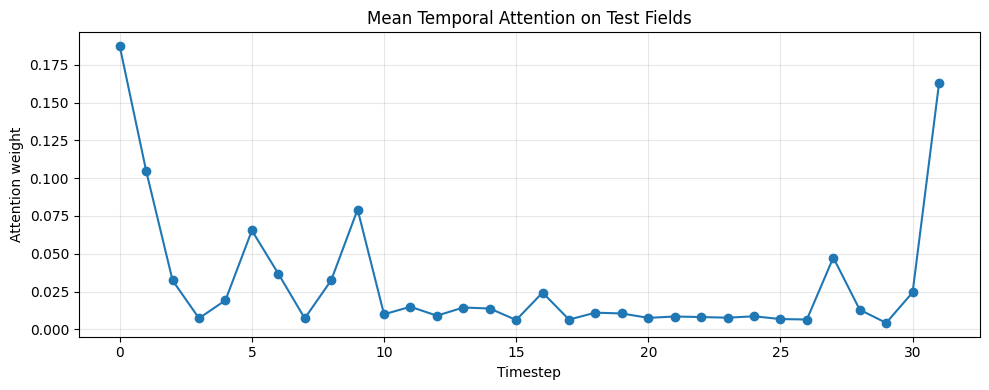

In [19]:
attention_df = pd.DataFrame({
    "timestep": np.arange(N_SEQUENCE_STEPS),
    "mean_attention": test_attention.mean(axis=0),
    "median_attention": np.median(test_attention, axis=0),
})

print("Top attention timesteps:")
display(attention_df.sort_values("mean_attention", ascending=False).head(10))

plt.figure(figsize=(10, 4))
plt.plot(attention_df["timestep"], attention_df["mean_attention"], marker="o")
plt.title("Mean Temporal Attention on Test Fields")
plt.xlabel("Timestep")
plt.ylabel("Attention weight")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Sequence Feature Importance

Permutation importance estimates which spectral time-series channels matter most by shuffling one feature across held-out fields and measuring macro-F1 drop.


,feature,macro_f1_drop,accuracy_drop
0,feat_s2_B06_mean,0.255027,0.239389
1,feat_s2_NDRE_mean,0.208020,0.205433
2,feat_s2_B04_mean,0.165084,0.148557
3,feat_s2_NDVI_mean,0.158462,0.138370
4,feat_s2_EVI_mean,0.152917,0.147708
5,feat_s2_NDMI_mean,0.152905,0.142615
6,feat_s2_SAVI_mean,0.147533,0.133277
7,feat_s2_B07_mean,0.129820,0.138370
8,feat_s2_B08_mean,0.120525,0.112054
9,feat_s2_B05_mean,0.119245,0.116299


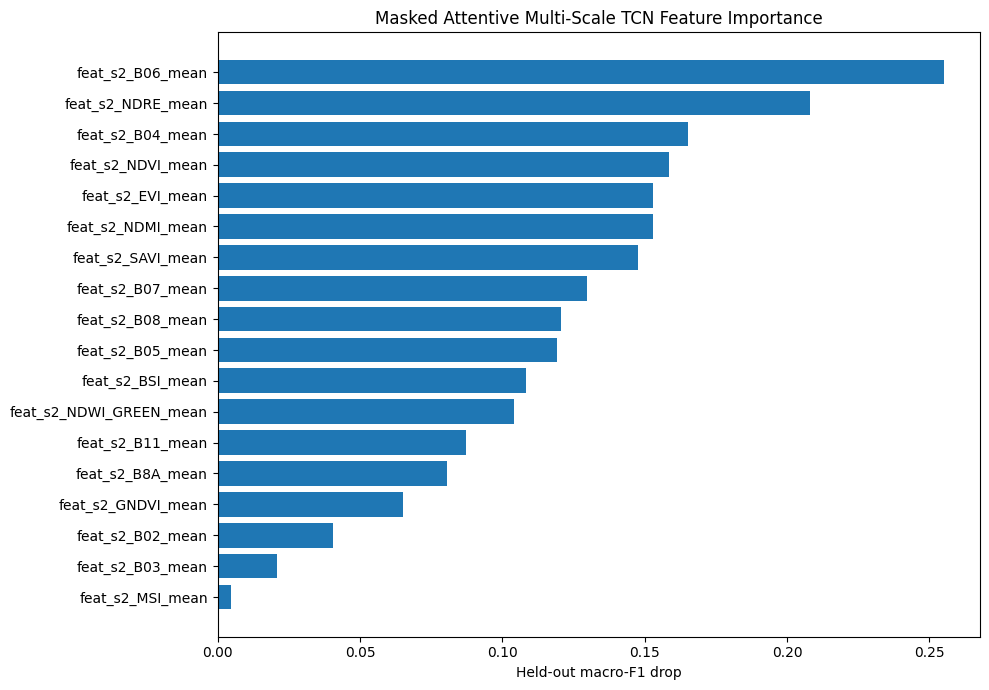

In [20]:
base_accuracy = accuracy_score(y_test, test_pred)
base_macro_f1 = f1_score(y_test, test_pred, average="macro", labels=metric_labels, zero_division=0)
rng = np.random.default_rng(RANDOM_SEED)

importance_rows = []
for feature_index, feature_name in enumerate(FEATURE_KEYS):
    shuffled_rows = rng.permutation(X_test.shape[0])
    X_perm = X_test.copy()
    X_perm[:, :, feature_index] = X_perm[shuffled_rows, :, feature_index]
    perm_probs, perm_pred, _ = predict_model(model, X_perm, mask_test)
    perm_accuracy = accuracy_score(y_test, perm_pred)
    perm_macro_f1 = f1_score(y_test, perm_pred, average="macro", labels=metric_labels, zero_division=0)
    importance_rows.append({
        "feature": feature_name,
        "macro_f1_drop": base_macro_f1 - perm_macro_f1,
        "accuracy_drop": base_accuracy - perm_accuracy,
    })

importance = (
    pd.DataFrame(importance_rows)
    .sort_values("macro_f1_drop", ascending=False)
    .reset_index(drop=True)
)

display(importance)

plt.figure(figsize=(10, 7))
plot_df = importance.head(18).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["macro_f1_drop"])
plt.title("Masked Attentive Multi-Scale TCN Feature Importance")
plt.xlabel("Held-out macro-F1 drop")
plt.tight_layout()
plt.show()


## 13. Optional Artifact Save

This cell saves the trained TCN checkpoint and preprocessing metadata only when explicitly enabled. Generated model artifacts are local research outputs and should not be committed.


In [21]:
SAVE_ARTIFACTS = False

if SAVE_ARTIFACTS:
    artifact_dir = Path("data/models/combined_crop_temporal_tcn")
    artifact_dir.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "feature_keys": FEATURE_KEYS,
            "classes": label_encoder.classes_.tolist(),
            "preprocessor": preprocessor,
            "n_sequence_steps": N_SEQUENCE_STEPS,
            "architecture": "MaskedAttentiveMultiScaleTCN",
            "test_accuracy": float(test_accuracy),
            "test_macro_f1": float(test_macro_f1),
            "other_crop_weight_multiplier": OTHER_CROP_WEIGHT_MULTIPLIER,
        },
        artifact_dir / "model.pt",
    )
    print("Saved:", artifact_dir / "model.pt")
else:
    print("SAVE_ARTIFACTS is False; skipping model save.")


SAVE_ARTIFACTS is False; skipping model save.


## 14. Direct AOI Temporal TCN Check

This final section runs the trained in-memory TCN directly on known AOI seasons. It builds the same 18 spectral time-series channels from the AOI cube, applies the train-only preprocessor, and prints predictions without using unittest, joblib, weather, or a tabular pipeline.


In [22]:
import xarray as xr

AOI_DIR = first_existing_path([
    Path('../data/aoi_demo_01'),  # when this notebook runs with cwd=notebooks/
    Path('data/aoi_demo_01'),     # when this notebook runs with cwd=repo root
    Path(r'C:/Users/abdulhamed/Desktop/work/FarmTrust/data/aoi_demo_01'),
])
AOI_INDICES_PATH = AOI_DIR / 'indices_timeseries.csv'
AOI_CUBE_PATH = AOI_DIR / 'cube.zarr'
VALID_SCL = {2, 4, 5, 6}
AOI_SEASONS = {
    'C1': {'known_label': 'Corn', 'start': '2024-05-18', 'end': '2024-08-30'},
    'C3': {'known_label': 'Corn', 'start': '2025-06-15', 'end': '2025-09-11'},
    'C4': {'known_label': 'Alfalfa', 'start': '2025-10-05', 'end': '2026-05-31'},
}

print('Current working directory:', Path.cwd())
print('AOI dir:', AOI_DIR, '| exists=', AOI_DIR.exists())
print('AOI indices:', AOI_INDICES_PATH, '| exists=', AOI_INDICES_PATH.exists())
print('AOI cube:', AOI_CUBE_PATH, '| exists=', AOI_CUBE_PATH.exists())


def safe_div(num: float, den: float) -> float:
    return float('nan') if abs(den) < 1e-10 else num / den


def compute_vi_from_bands(band_means: dict[str, float]) -> dict[str, float]:
    b02 = band_means['B02']
    b03 = band_means['B03']
    b04 = band_means['B04']
    b05 = band_means['B05']
    b08 = band_means['B08']
    b11 = band_means['B11']
    return {
        's2_SAVI_mean': safe_div((b08 - b04) * 1.5, b08 + b04 + 0.5),
        's2_GNDVI_mean': safe_div(b08 - b03, b08 + b03),
        's2_NDRE_mean': safe_div(b08 - b05, b08 + b05),
        's2_MSI_mean': safe_div(b11, b08),
        's2_BSI_mean': safe_div((b11 + b04) - (b08 + b02), (b11 + b04) + (b08 + b02)),
    }


def spatial_mean_per_date(ds_10m, ds_20m, scl, dates: pd.Series) -> pd.DataFrame:
    bands = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11']
    rows = []
    time_idx = {pd.Timestamp(t).date(): i for i, t in enumerate(ds_10m.time.values)}
    scl_10m = scl.sel(y=ds_10m.y, x=ds_10m.x, method='nearest')

    for dt in dates:
        dt_date = pd.Timestamp(dt).date()
        if dt_date not in time_idx:
            continue

        ti = time_idx[dt_date]
        valid_mask = np.isin(scl_10m.isel(time=ti).values, list(VALID_SCL))
        valid_count = valid_mask.sum()
        if valid_count == 0:
            continue

        row = {'date': pd.Timestamp(dt)}
        band_means = {}
        for band in bands:
            if band in ds_10m:
                arr = ds_10m[band].isel(time=ti).values.astype(float)
            else:
                arr_20m = ds_20m[band].isel(time=ti).values.astype(float)
                arr = xr.DataArray(arr_20m, dims=['y', 'x'], coords={'y': ds_20m.y, 'x': ds_20m.x}).sel(
                    y=ds_10m.y,
                    x=ds_10m.x,
                    method='nearest',
                ).values

            mean_value = np.nansum(arr * valid_mask) / valid_count / 10000.0
            band_means[band] = mean_value
            row[f'feat_s2_{band}_mean'] = mean_value

        row.update({f'feat_{name}': value for name, value in compute_vi_from_bands(band_means).items()})
        rows.append(row)

    return pd.DataFrame(rows)


def build_aoi_sequence(season: dict[str, str], indices: pd.DataFrame, ds_10m, ds_20m, scl) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    start = pd.Timestamp(season['start'])
    end = pd.Timestamp(season['end'])
    dates_in_data = indices[
        (indices['solar_day'] >= start)
        & (indices['solar_day'] <= end)
        & (indices['valid_fraction'] > 0)
    ].copy()

    aoi_rows = spatial_mean_per_date(ds_10m, ds_20m, scl, dates_in_data['solar_day'])
    if len(aoi_rows) == 0:
        empty_obs = pd.DataFrame(columns=['date'] + FEATURE_KEYS)
        sequence, mask = make_fixed_length_sequence(empty_obs, FEATURE_KEYS, N_SEQUENCE_STEPS)
        return sequence[None, :, :], mask[None, :], aoi_rows

    csv_features = {
        'feat_s2_NDVI_mean': 'ndvi_mean',
        'feat_s2_EVI_mean': 'evi_mean',
        'feat_s2_NDMI_mean': 'ndmi_mean',
        'feat_s2_NDWI_GREEN_mean': 'ndwi_mean',
    }
    aoi_rows = aoi_rows.merge(
        dates_in_data[['solar_day'] + list(csv_features.values())].rename(columns={'solar_day': 'date'}),
        on='date',
        how='left',
    )
    for feature_key, csv_col in csv_features.items():
        aoi_rows[feature_key] = aoi_rows[csv_col]

    missing = [feature for feature in FEATURE_KEYS if feature not in aoi_rows.columns]
    if missing:
        raise RuntimeError(f'AOI sequence is missing model features: {missing}')

    sequence, mask = make_fixed_length_sequence(aoi_rows[['date'] + FEATURE_KEYS], FEATURE_KEYS, N_SEQUENCE_STEPS)
    return sequence[None, :, :], mask[None, :], aoi_rows


def predict_aoi_seasons() -> pd.DataFrame:
    indices = pd.read_csv(AOI_INDICES_PATH, parse_dates=['solar_day'])
    ds_10m = xr.open_zarr(AOI_CUBE_PATH, consolidated=False)
    ds_20m = xr.open_zarr(AOI_CUBE_PATH, group='20m', consolidated=False)
    scl = ds_20m['SCL']

    rows = []
    for season_name, season in AOI_SEASONS.items():
        raw_sequence, raw_mask, aoi_rows = build_aoi_sequence(season, indices, ds_10m, ds_20m, scl)
        X_aoi = transform_sequences(raw_sequence, raw_mask, preprocessor)
        probs, pred_idx, attention = predict_model(model, X_aoi, raw_mask)
        ranked = sorted(
            zip(label_encoder.classes_, probs[0], strict=True),
            key=lambda item: item[1],
            reverse=True,
        )
        predicted = label_encoder.classes_[pred_idx[0]]
        rows.append({
            'season': season_name,
            'known_label': season['known_label'],
            'predicted_label': predicted,
            'is_correct': predicted == season['known_label'],
            'valid_observations': len(aoi_rows),
            'valid_timesteps': int(raw_mask.sum()),
            'top_probabilities': ', '.join(f'{name}={score:.3f}' for name, score in ranked),
            'top_attention_timestep': int(attention[0].argmax()),
        })

    return pd.DataFrame(rows)


aoi_results = predict_aoi_seasons()
display(aoi_results)


Current working directory: c:\Users\abdulhamed\Desktop\work\FarmTrust\notebooks
AOI dir: ..\data\aoi_demo_01 | exists= True
AOI indices: ..\data\aoi_demo_01\indices_timeseries.csv | exists= True
AOI cube: ..\data\aoi_demo_01\cube.zarr | exists= True


,season,known_label,predicted_label,is_correct,valid_observations,valid_timesteps,top_probabilities,top_attention_timestep
0,C1,Corn,Wheat,False,39,31,"Wheat=0.992, Alfalfa=0.004, Other crop=0.002, ...",22
1,C3,Corn,Wheat,False,39,30,"Wheat=0.971, Alfalfa=0.016, Corn=0.005, Other ...",27
2,C4,Alfalfa,Wheat,False,67,31,"Wheat=0.518, Alfalfa=0.455, Background=0.012, ...",30
